In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')
# Show all columns without truncation
pd.set_option("display.max_columns", None)

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')


In [2]:
df = pd.read_csv("D:\Customer-Churn-Analytics\Data\customer_rfm.csv")
df.head(3)

,customer_id,customer_name,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment,churn
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,9,Potential Loyalists,1
1,AA-10375,Allen Armold,20,9,1056.390,5,5,2,12,Loyal Customers,0
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,5,At Risk,1


### Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       793 non-null    str    
 1   customer_name     793 non-null    str    
 2   recency           793 non-null    int64  
 3   frequency         793 non-null    int64  
 4   monetary          793 non-null    float64
 5   r_score           793 non-null    int64  
 6   f_score           793 non-null    int64  
 7   m_score           793 non-null    int64  
 8   rfm_score         793 non-null    int64  
 9   customer_segment  793 non-null    str    
 10  churn             793 non-null    int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 95.0 KB


In [4]:
df.shape

(793, 11)

In [5]:
df.isnull().sum()

customer_id         0
customer_name       0
recency             0
frequency           0
monetary            0
r_score             0
f_score             0
m_score             0
rfm_score           0
customer_segment    0
churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()


,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,churn
count,793.000000,793.000000,793.000000,793.000000,793.000000,793.000000,793.000000,793.000000
mean,147.802018,6.316520,2896.848500,3.006305,3.000000,3.000000,9.006305,0.452711
std,186.211051,2.550885,2628.670117,1.419991,1.415998,1.415998,3.200570,0.498073
min,1.000000,1.000000,4.833000,1.000000,1.000000,1.000000,3.000000,0.000000
25%,31.000000,5.000000,1146.050000,2.000000,2.000000,2.000000,7.000000,0.000000
50%,76.000000,6.000000,2256.394000,3.000000,3.000000,3.000000,9.000000,0.000000
75%,184.000000,8.000000,3785.276000,4.000000,4.000000,4.000000,11.000000,1.000000
max,1166.000000,17.000000,25043.050000,5.000000,5.000000,5.000000,15.000000,1.000000


* Checked the structure, data types, summary statistics, and missing values before preprocessing.

## Feature Selection

In [37]:
# select feature X and target y
X = df.drop(columns=['customer_id', 'customer_name','churn'])

y = df['churn']
X.head()

,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,185,5,5563.560,2,2,5,9,Potential Loyalists
1,20,9,1056.390,5,5,2,12,Loyal Customers
2,260,4,1790.512,1,1,3,5,At Risk
3,56,6,5086.935,3,3,5,11,Loyal Customers
4,416,3,886.156,1,1,1,3,Lost Customers


In [38]:
y.value_counts() # non churn = 434, churned = 359

churn
0    434
1    359
Name: count, dtype: int64

## Encode Categorical Features

In [39]:
segment_order = {
    'Lost Customers': 0,
    'At Risk': 1,
    'Potential Loyalists': 2,
    'Loyal Customers': 3,
    'Champions': 4,
}

X['customer_segment'] = X['customer_segment'].map(segment_order)

X['customer_segment'].astype(int)

X.info()
X.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   recency           793 non-null    int64  
 1   frequency         793 non-null    int64  
 2   monetary          793 non-null    float64
 3   r_score           793 non-null    int64  
 4   f_score           793 non-null    int64  
 5   m_score           793 non-null    int64  
 6   rfm_score         793 non-null    int64  
 7   customer_segment  793 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 49.7 KB


,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,customer_segment
0,185,5,5563.560,2,2,5,9,2
1,20,9,1056.390,5,5,2,12,3
2,260,4,1790.512,1,1,3,5,1


In [40]:
X['customer_segment'].value_counts()

customer_segment
3    254
2    219
1    157
4    124
0     39
Name: count, dtype: int64

## Train Test Split

In [41]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.20, random_state=42, stratify=y)


In [42]:
print('X train shape: ',X_train.shape)
print('y train shape: ',y_train.shape)
print()
print('X test shape: ',X_test.shape)
print('y test shape: ',y_test.shape)


X train shape:  (634, 8)
y train shape:  (634,)

X test shape:  (159, 8)
y test shape:  (159,)


## Feature Scaling

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Models**
* Naive bayes 
* Decision Tree
* Random Forest 

## **1- Naive Bayes**

In [44]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

# Train the Model 

nb_model.fit(X_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [45]:
y_pred_nb = nb_model.predict(X_test_scaled)

### **Naive Bayes Evaluation**

In [46]:
# Predict Churn Probabilities

y_prob_nb = nb_model.predict(X_test_scaled)

In [47]:
from sklearn.metrics import (confusion_matrix,accuracy_score, precision_score,
recall_score,f1_score, roc_auc_score, classification_report,ConfusionMatrixDisplay)

# Calculate Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
roc_auc = roc_auc_score(y_test, y_prob_nb)

In [48]:
# Display Model Performance

print("Naive Bayes Performance:\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Naive Bayes Performance:

Accuracy : 0.9057
Precision: 0.9014
Recall   : 0.8889
F1 Score : 0.8951
ROC AUC  : 0.9042


In [49]:
# classification report 
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91        87
           1       0.90      0.89      0.90        72

    accuracy                           0.91       159
   macro avg       0.91      0.90      0.90       159
weighted avg       0.91      0.91      0.91       159



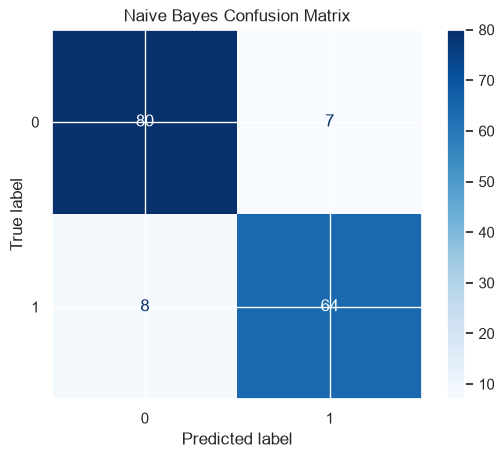

In [50]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_nb)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.show()

## Business Summary

- Built a Gaussian Naive Bayes model to predict customer churn.
- Evaluated the model using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
    * About 90.6% of customers were classified correctly.
    * When the model predicted a customer would churn, it was correct about 90% of the time.
    * The model identified about 88.9% of actual churners.
    * The model separates churners from non-churners very well.
    


---
---

### **2- K-Nearest Neighbors**

In [51]:
# first lets find the best k values for n_neightbor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    accuracy_scores.append(accuracy_score(y_test, y_pred_knn))

best_k = k_values[accuracy_scores.index(max(accuracy_scores))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracy_scores))

Best K: 5
Best Accuracy: 0.9119496855345912


In [52]:
# now lets 
knn_model = KNeighborsClassifier(n_neighbors=5)

# train model 
knn_model.fit(X_train_scaled,y_train)

# prediction
y_pred_knn = knn_model.predict(X_test_scaled)

In [53]:
from sklearn.metrics import (confusion_matrix,accuracy_score, precision_score,
recall_score,f1_score, roc_auc_score, classification_report,ConfusionMatrixDisplay)

# Calculate Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
roc_auc = roc_auc_score(y_test, y_pred_knn)

In [54]:
# Display Model Performance

print("K Nearest Neighbors Performance:\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

K Nearest Neighbors Performance:

Accuracy : 0.9119
Precision: 0.9531
Recall   : 0.8472
F1 Score : 0.8971
ROC AUC  : 0.9064


In [55]:
# classification report 
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92        87
           1       0.95      0.85      0.90        72

    accuracy                           0.91       159
   macro avg       0.92      0.91      0.91       159
weighted avg       0.92      0.91      0.91       159



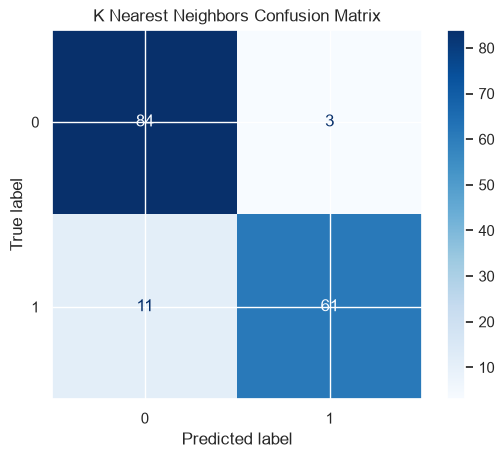

In [56]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

plt.title("K Nearest Neighbors Confusion Matrix")
plt.show()

## Business Summary

The K-Nearest Neighbors model (K = 5) achieved an **accuracy of 91.19%**, **precision of 95.31%**, **recall of 84.72%**, **F1 Score of 89.71%**, and **ROC-AUC of 90.64%**. The model demonstrated excellent precision, making its churn predictions highly reliable but still its lower recall indicates that some actual churning customers were missed

---
---

### **3- Random Forest**

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# train the model
rf_model.fit(X_train,y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

In [58]:
from sklearn.metrics import (confusion_matrix,accuracy_score, precision_score,
recall_score,f1_score, roc_auc_score, classification_report,ConfusionMatrixDisplay)

# Calculate Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_pred_rf)

In [59]:
# Display Model Performance

print("Random Forest Performance:\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Random Forest Performance:

Accuracy : 0.9937
Precision: 1.0000
Recall   : 0.9861
F1 Score : 0.9930
ROC AUC  : 0.9931


In [ ]:
# classification report 
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        87
           1       1.00      0.99      0.99        72

    accuracy                           0.99       159
   macro avg       0.99      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159



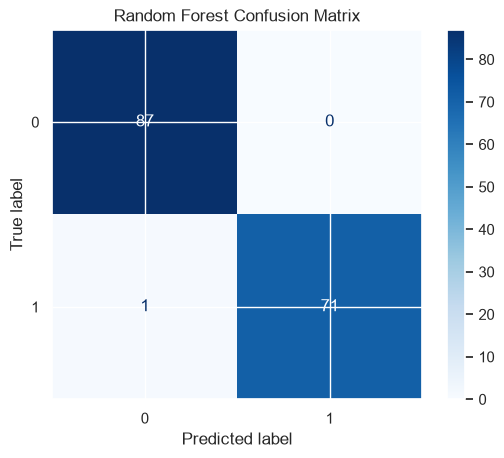

In [61]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.show()


# Model Comparison

### Naive Bayes
- Accuracy: 90.57%
- Precision: 90.14%
- Recall: 88.89%
- F1 Score: 89.51%
- ROC-AUC: 90.42%

### K-Nearest Neighbors (KNN)
- Accuracy: 91.19%
- Precision: 95.31%
- Recall: 84.72%
- F1 Score: 89.71%
- ROC-AUC: 90.64%

### Random Forest
- Accuracy: 99.37%
- Precision: 100.00%
- Recall: 98.61%
- F1 Score: 99.30%
- ROC-AUC: 99.31%

## Conclusion

Among all three models, **Random Forest** performed the best. It achieved the highest accuracy, precision, recall, F1 score, and ROC-AUC. Therefore, Random Forest was selected as the final model for predicting customer churn in this project.

In [62]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

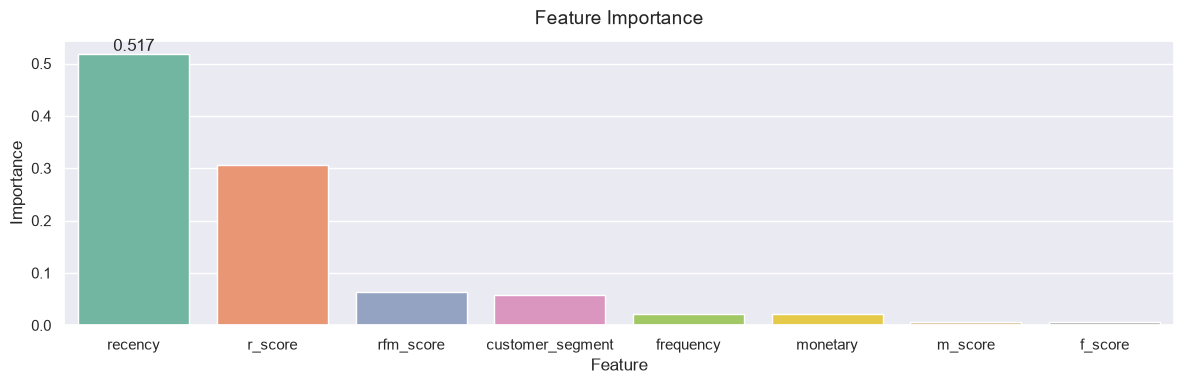

In [78]:
plt.figure(figsize=(12,4))
ax = sns.barplot(data=feature_importance, x='Feature', y='Importance', palette='Set2',)
plt.title('Feature Importance', fontsize=14, pad=12)

# Add labels on bars
ax.bar_label(ax.containers[0], fmt='%.3f')

plt.tight_layout()
plt.show()

## Business Insight

The feature importance chart shows which features had the biggest impact on predicting customer churn.

Features with higher importance influenced the model more than the others. These insights can help businesses understand customer behavior and focus on customers who are more likely to churn.

----

# Machine Learning Conclusion

Three machine learning models were trained and evaluated to predict customer churn.

Among them, **Random Forest** achieved the best performance with the highest accuracy, precision, recall, F1 score, and ROC-AUC. Therefore, it was selected as the final model for this project.

The trained model was saved using Joblib and will be used in the Streamlit web application for customer churn prediction.

---

---
# Project Limitation

The original dataset did not contain a customer churn label. Therefore, a proxy churn label was created using customer recency (customers with recency greater than 90 days were considered churned).

Because the target was created from customer behavior, the machine learning results may be higher than those of a real-world churn prediction model.

The main goal of this project is to demonstrate the complete data analytics and machine learning workflow, including data cleaning, EDA, RFM analysis, feature engineering, model building, evaluation, and deployment.

In [105]:
X2 = df[['recency','frequency','monetary']]
y = df['churn']

X2_train, X2_test, y_train,y_test = train_test_split(X2, y, test_size=0.20, random_state=42, stratify=y)

In [106]:
# Random forest model 2 for future customers prediction 
rf_model.fit(X2_train, y_train)

y2_pred_rfm = rf_model.predict(X2_test)

In [107]:
from sklearn.metrics import (confusion_matrix,accuracy_score, precision_score,
recall_score,f1_score, roc_auc_score, classification_report,ConfusionMatrixDisplay)

# Calculate Evaluation Metrics

accuracy = accuracy_score(y_test, y2_pred_rfm)
precision = precision_score(y_test, y2_pred_rfm)
recall = recall_score(y_test, y2_pred_rfm)
f1 = f1_score(y_test, y2_pred_rfm)
roc_auc = roc_auc_score(y_test, y2_pred_rfm)

In [108]:
# Display Model Performance

print("Random Forest Performance:\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Random Forest Performance:

Accuracy : 0.9937
Precision: 1.0000
Recall   : 0.9861
F1 Score : 0.9930
ROC AUC  : 0.9931


In [109]:
import joblib

joblib.dump(rf_model, "D:\\Customer-Churn-Analytics\\Models\\Random_forest_model.pkl")

['D:\\Customer-Churn-Analytics\\Models\\Random_forest_model.pkl']